# Laplacian scale space representations

The concept of a scale space refers to a framework for working with a signal, in this case images, as a collection of signals each describing information at different length scales.

## Lab Homework: Laplacian Pyramid Computation

### Objective
In this homework assignment, we'll explore Laplacian pyramids, a powerful technique for image processing and multi-scale representation. Laplacian pyramids are particularly useful for image compression, blending, and feature extraction.

## Prerequisites
First, let's import our required libraries:

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from typing import List, Tuple

In [6]:
img = cv2.imread("image1.jpeg", cv2.IMREAD_COLOR)

## Part 1: Understanding the Building Blocks

### 1.1 Next Pyramid Layer Function
The following function computes the next layer of the pyramid. Study it carefully and answer the questions below.


In [7]:
def next_pyramid_layer(img: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute the next layer of the Laplacian pyramid.

    Args:
        img: Input image array of shape (bands, height, width)

    Returns:
        tuple: (residual, downsampled)
            - residual: Difference between original and upsampled image
            - downsampled: Reduced resolution image
    """
    # Downsample each band
    down = np.stack([cv2.pyrDown(layer) for layer in img])

    # Upsample the downsampled image
    up = np.stack([cv2.pyrUp(layer) for layer in down])

    # Get original dimensions
    nr, nc = img.shape[1:]

    # Calculate residual (difference between original and upsampled)
    resid = img - up[:,:nr,:nc]

    return resid, down

In [8]:
next_pyramid_layer(img)

(array([[[  7,   6,   8],
         [252, 251, 253],
         [  0, 254,   0],
         ...,
         [232, 236, 232],
         [  0,   5, 250],
         [  5,   8,   0]],
 
        [[  2,   1,   3],
         [253, 252, 254],
         [  2,   1,   3],
         ...,
         [240, 244, 233],
         [  7,  10,   2],
         [240, 243, 241]],
 
        [[  5,   4,   6],
         [  1,   0,   2],
         [250, 248, 250],
         ...,
         [242, 246, 236],
         [ 19,  21,  16],
         [228, 230, 225]],
 
        ...,
 
        [[ 10, 254, 253],
         [255, 244, 243],
         [250, 242, 240],
         ...,
         [217, 216, 218],
         [239, 235, 236],
         [ 48,  43,  45]],
 
        [[ 22,  10,  12],
         [  2, 248, 250],
         [254, 245, 246],
         ...,
         [231, 231, 231],
         [243, 239, 239],
         [ 23,  18,  19]],
 
        [[247, 238, 239],
         [ 11,   1,   2],
         [ 13,   6,   7],
         ...,
         [236, 236, 236],
  

### Questions for Part 1 (Not Graded):
 1. Why do we need to use np.stack() when processing the image?
      
      Because the image is represented as (bands, height, width). Each band (channel) is processed separately by cv2.pyrDown or cv2.pyrUp. np.stack() reassembles the processed channels back into a single multiband array, preserving the original structure.

 2. What is the purpose of slicing up[:,:nr,:nc]?

     Upsampling often produces slightly larger dimensions than the original due to rounding. Slicing ensures the upsampled image matches the original dimensions (nr, nc) before subtraction, so the residual calculation is valid.

 3. What would happen if we didn't match the dimensions in the subtraction?

      If dimensions don’t match, either get a broadcasting error (NumPy cannot subtract arrays of different shapes) or misaligned subtraction, leading to incorrect residuals. This would break the Laplacian pyramid construction because the residuals wouldn’t represent the true difference between the original and reconstructed image.

## Part 2: The Complete Pyramid

### 2.1 Laplacian Pyramid Function
Now let's examine the full pyramid construction:

In [11]:
def laplacian_pyramid(img: np.ndarray, max_layers: int = 100) -> List[np.ndarray]:
    """
    Compute Laplacian pyramid for a multiband image.

    Args:
        img: Input image array of shape (bands, height, width)
        max_layers: Maximum number of pyramid layers to compute

    Returns:
        list: Pyramid layers [residual1, residual2, ..., residualN, gaussian_remainder]
    """
    layers = []
    down = img
    prev_size = down.size

    for i in range(max_layers):
        resid, down = next_pyramid_layer(down)

        # Check if we've reached the smallest possible size
        if down.size == prev_size:
            break

        prev_size = down.size
        layers.append(resid)

    # Add the final Gaussian remainder
    layers.append(down)
    return layers

In [17]:
laplacian_pyramid(img, max_layers=5)

[array([[[-7.51032829e-02, -1.22242630e-01, -1.10537887e-01, ...,
          -9.75470990e-02, -2.79071890e-02, -6.00107387e-03],
         [ 1.91567123e-01,  1.75520837e-01,  1.89559340e-01, ...,
          -8.69140625e-02,  1.43647194e-05, -6.90487102e-02],
         [ 4.32705879e-03, -1.60511136e-02, -4.73405719e-02, ...,
          -4.47265580e-02,  9.65834707e-02, -8.76857340e-02],
         ...,
         [-1.32839292e-01, -1.66444570e-01, -1.72276169e-01, ...,
          -1.61714926e-01, -9.37318206e-02,  1.60301775e-01],
         [ 1.85676157e-01,  1.04968965e-01,  7.05807805e-02, ...,
          -1.51075184e-01, -1.32574350e-01,  3.00435722e-03],
         [ 1.06227040e-01,  1.82368219e-01,  1.93363190e-01, ...,
          -1.94240361e-02,  8.45434964e-02,  1.96323544e-01]],
 
        [[-7.51033425e-02, -1.22242689e-01, -1.10591471e-01, ...,
          -1.13543585e-01, -1.76686123e-02, -2.70374119e-03],
         [ 1.91567123e-01,  1.75520837e-01,  1.89513385e-01, ...,
          -7.43298158

## Part 3: Practical Exercises

### Exercise 1: Basic Pyramid Construction
Complete the following code to build and visualize a Laplacian pyramid for the provided `image1.jpeg`:


In [18]:
def load_and_prepare_image(path: str) -> np.ndarray:
    """
    TODO: Write a function that:
    1. Loads an image using cv2.imread
    2. Converts it to floating point (0-1 range)
    3. Transposes it to (channel, height, width) order
    """

    # Load image using cv2.imread (BGR format by default)
    img = cv2.imread("image1.jpeg", cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Image not found at {path}")

    # Convert to RGB for consistency
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Normalize to floating point [0,1]
    img = img.astype(np.float32) / 255.0

    # Transpose to (channels, height, width)
    img = np.transpose(img, (2, 0, 1))

    return img
    pass

In [19]:
load_and_prepare_image("image1.jpeg")

array([[[0.7490196 , 0.7019608 , 0.7176471 , ..., 0.        ,
         0.03921569, 0.05098039],
        [0.9882353 , 0.972549  , 0.99215686, ..., 0.01960784,
         0.07843138, 0.        ],
        [0.7411765 , 0.72156864, 0.69803923, ..., 0.07843138,
         0.19607843, 0.00392157],
        ...,
        [0.37254903, 0.34509805, 0.3647059 , ..., 0.03137255,
         0.05490196, 0.29411766],
        [0.7764706 , 0.7019608 , 0.6862745 , ..., 0.02352941,
         0.        , 0.12156863],
        [0.7254902 , 0.80784315, 0.8352941 , ..., 0.14901961,
         0.21176471, 0.30980393]],

       [[0.7411765 , 0.69411767, 0.70980394, ..., 0.01960784,
         0.08235294, 0.08627451],
        [0.98039216, 0.9647059 , 0.9843137 , ..., 0.06666667,
         0.11372549, 0.01176471],
        [0.73333335, 0.7137255 , 0.6901961 , ..., 0.12156863,
         0.21960784, 0.02745098],
        ...,
        [0.38039216, 0.3529412 , 0.3764706 , ..., 0.02352941,
         0.05098039, 0.2901961 ],
        [0.7

In [29]:
def visualize_pyramid(pyramid: List[np.ndarray]) -> None:
    """
    TODO: Write a function that:
    1. Creates a figure with len(pyramid) subplots
    2. Displays each layer of the pyramid
    3. Shows the residual layers with a diverging colormap
    4. Shows the final Gaussian remainder in grayscale
    """
    num_layers = len(pyramid)
    fig, axes = plt.subplots(1, num_layers, figsize=(20, 5))

    if num_layers == 1:
        axes = [axes]  # handle single-layer case

    for i, layer in enumerate(pyramid):
        # Transpose back to (height, width, channels) for visualization
        img = np.transpose(layer, (1, 2, 0))

        if i < num_layers - 1:  # Residual layers
            axes[i].imshow(img, cmap='seismic')  # diverging colormap highlights positive/negative residuals
            axes[i].set_title(f"Residual {i+1}")
        else:  # Final Gaussian remainder
            if img.shape[2] == 1:  # grayscale
                axes[i].imshow(img.squeeze(), cmap='gray')
            else:  # color
                axes[i].imshow(img)
            axes[i].set_title("Gaussian Remainder")

        axes[i].axis('off')

    plt.tight_layout()
    plt.imshow
    pass


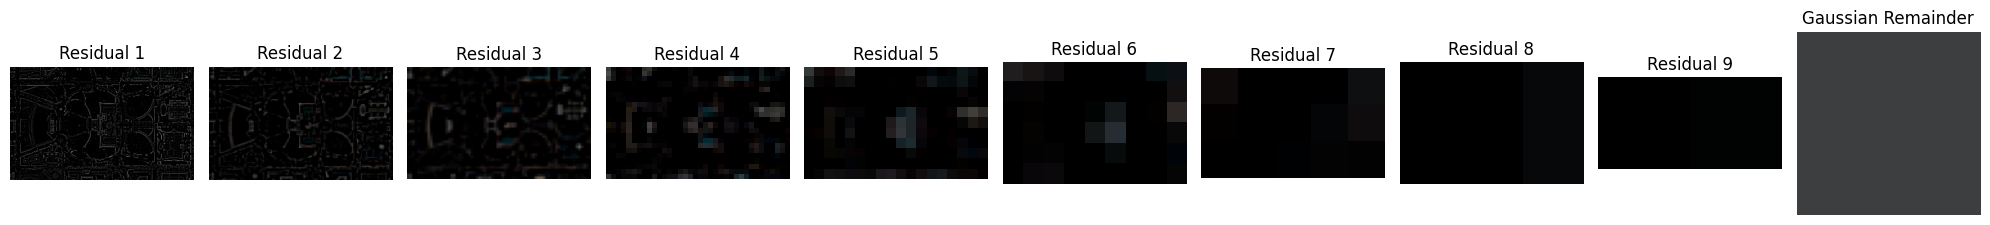

In [30]:
visualize_pyramid(laplacian_pyramid(load_and_prepare_image("image1.jpeg")))

### Exercise 2: Pyramid Analysis

Write functions to answer the following questions:

In [31]:
def analyze_pyramid(pyramid: List[np.ndarray]) -> dict:
    """
    TODO: Create a function that returns a dictionary containing:
    1. The number of layers in the pyramid
    2. The size reduction ratio between consecutive layers
    3. The total memory usage of the pyramid vs. original image
    4. The amount of information (variance) in each residual layer
    """
    pass

    analysis = {
        "num_layers": len(pyramid),
        "size_ratios": [],
        "memory_usage": {},
        "residual_variance": []
    }

    # 1. Number of layers
    num_layers = len(pyramid)
    analysis["num_layers"] = num_layers

    # 2. Size reduction ratios between consecutive layers
    for i in range(num_layers - 1):
        h1, w1 = pyramid[i].shape[1:]
        h2, w2 = pyramid[i+1].shape[1:]
        ratio_h = h2 / h1
        ratio_w = w2 / w1
        analysis["size_ratios"].append((ratio_h, ratio_w))

    # 3. Memory usage
    original_size = pyramid[0].nbytes
    total_size = sum(layer.nbytes for layer in pyramid)
    analysis["memory_usage"]["original"] = original_size
    analysis["memory_usage"]["pyramid_total"] = total_size
    analysis["memory_usage"]["compression_ratio"] = total_size / original_size

    # 4. Variance in each residual layer (amount of information)
    for i, layer in enumerate(pyramid[:-1]):  # exclude final Gaussian remainder
        var = np.var(layer)
        analysis["residual_variance"].append((i+1, var))

    return analysis

In [32]:
analyze_pyramid(laplacian_pyramid(load_and_prepare_image("image1.jpeg")))

{'num_layers': 10,
 'size_ratios': [(0.5, 0.5),
  (0.5, 0.5034965034965035),
  (0.5, 0.5),
  (0.5, 0.5),
  (0.5454545454545454, 0.5),
  (0.5, 0.5555555555555556),
  (0.6666666666666666, 0.6),
  (0.5, 0.6666666666666666),
  (1.0, 0.5)],
 'memory_usage': {'original': 604032,
  'pyramid_total': 805872,
  'compression_ratio': 1.3341544818817546},
 'residual_variance': [(1, np.float32(0.0130819315)),
  (2, np.float32(0.005556295)),
  (3, np.float32(0.005045347)),
  (4, np.float32(0.005025063)),
  (5, np.float32(0.0048708147)),
  (6, np.float32(0.0031130416)),
  (7, np.float32(0.0011261867)),
  (8, np.float32(0.0005054001)),
  (9, np.float32(5.8372814e-05))]}

### Exercise 3: Image Reconstruction

In [33]:
def reconstruct_from_pyramid(pyramid: List[np.ndarray]) -> np.ndarray:
    """
    TODO: Write a function that:
    1. Takes a Laplacian pyramid as input
    2. Reconstructs the original image by reversing the pyramid operations
    3. Returns the reconstructed image

    Hint: You'll need to use cv2.pyrUp() and handle the dimensions carefully
    """

    # Start from the smallest Gaussian remainder
    current = pyramid[-1]

    # Work backwards through residuals
    for resid in reversed(pyramid[:-1]):
        # Upsample current image for each channel
        up = np.stack([cv2.pyrUp(layer) for layer in current])

        # Match dimensions to residual
        nr, nc = resid.shape[1:]
        up = up[:, :nr, :nc]

        # Add residual back
        current = resid + up

    return current
    pass

In [34]:
reconstruct_from_pyramid(laplacian_pyramid(load_and_prepare_image("image1.jpeg")))

array([[[ 7.49019623e-01,  7.01960802e-01,  7.17647076e-01, ...,
          0.00000000e+00,  3.92156877e-02,  5.09803928e-02],
        [ 9.88235295e-01,  9.72549021e-01,  9.92156863e-01, ...,
          1.96078420e-02,  7.84313753e-02,  0.00000000e+00],
        [ 7.41176486e-01,  7.21568525e-01,  6.98039174e-01, ...,
          7.84313753e-02,  1.96078435e-01,  3.92156839e-03],
        ...,
        [ 3.72549027e-01,  3.45098048e-01,  3.64705890e-01, ...,
          3.13725173e-02,  5.49019277e-02,  2.94117600e-01],
        [ 7.76470602e-01,  7.01960802e-01,  6.86274529e-01, ...,
          2.35293806e-02, -1.49011612e-08,  1.21568590e-01],
        [ 7.25490212e-01,  8.07843149e-01,  8.35294127e-01, ...,
          1.49019584e-01,  2.11764678e-01,  3.09803903e-01]],

       [[ 7.41176486e-01,  6.94117665e-01,  7.09803939e-01, ...,
          1.96078420e-02,  8.23529437e-02,  8.62745121e-02],
        [ 9.80392158e-01,  9.64705884e-01,  9.84313726e-01, ...,
          6.66666701e-02,  1.13725491e

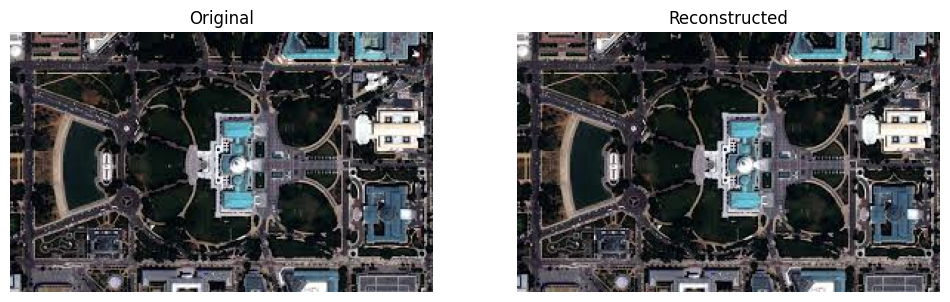

In [35]:
img = load_and_prepare_image("image1.jpeg")
pyramid = laplacian_pyramid(img, max_layers=5)

# Reconstruct
reconstructed = reconstruct_from_pyramid(pyramid)

# Compare original vs reconstructed
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(np.transpose(img, (1,2,0)))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(np.transpose(reconstructed, (1,2,0)))
plt.title("Reconstructed")
plt.axis("off")
plt.show()

## Submission Instructions

For this homework, please submit:
1. Your completed Python notebook with all exercises implemented
2. Example outputs using at least two different images

## Extra Credit
Implement one of the following:
1. Image blending using Laplacian pyramids
2. A modified pyramid structure that preserves color information better

Good luck!

In [56]:
# Gaussian Pyramid
def build_gaussian_pyramid(img: np.ndarray, levels: int) -> List[np.ndarray]:
    gp = [img.astype(np.float32)]
    for _ in range(levels):
        img = cv2.pyrDown(img)
        gp.append(img.astype(np.float32))
    return gp

# Laplacian Pyramid
def build_laplacian_pyramid(img: np.ndarray, levels: int) -> List[np.ndarray]:
    gp = build_gaussian_pyramid(img, levels)
    lp = []

    for i in range(levels):
        size = (gp[i].shape[1], gp[i].shape[0])
        expanded = cv2.pyrUp(gp[i+1], dstsize=size)
        laplacian = gp[i] - expanded
        lp.append(laplacian)

    lp.append(gp[-1])  # last Gaussian level
    return lp

# Pyramid Blending
def blend_pyramids(lpA: List[np.ndarray],
                   lpB: List[np.ndarray],
                   gpMask: List[np.ndarray]) -> List[np.ndarray]:
    blended_pyramid = []

    for la, lb, gm in zip(lpA, lpB, gpMask):
        if gm.ndim == 2:
            gm = gm[..., np.newaxis]
        blended = la * gm + lb * (1 - gm)
        blended_pyramid.append(blended)

    return blended_pyramid

# Reconstruct Image
def reconstruct_from_pyramid(pyramid: List[np.ndarray]) -> np.ndarray:
    img = pyramid[-1]

    for i in range(len(pyramid) - 2, -1, -1):
        size = (pyramid[i].shape[1], pyramid[i].shape[0])
        img = cv2.pyrUp(img, dstsize=size) + pyramid[i]

    return np.clip(img, 0, 1)

# Main Blending Function
def laplacian_pyramid_blending(imgA: np.ndarray,
                               imgB: np.ndarray,
                               mask: np.ndarray,
                               levels: int = 5) -> np.ndarray:
    """
    Blend two images using Laplacian Pyramid Blending.

    Args:
        imgA: First image (float32, [0,1])
        imgB: Second image (float32, [0,1])
        mask: Blending mask (1 for imgA, 0 for imgB)
        levels: Number of pyramid levels

    Returns:
        Blended image
    """
    # Build pyramids
    gpMask = build_gaussian_pyramid(mask, levels)
    lpA = build_laplacian_pyramid(imgA, levels)
    lpB = build_laplacian_pyramid(imgB, levels)

    # Blend pyramids
    blended_pyramid = blend_pyramids(lpA, lpB, gpMask)

    # Reconstruct
    blended = reconstruct_from_pyramid(blended_pyramid)

    return blended

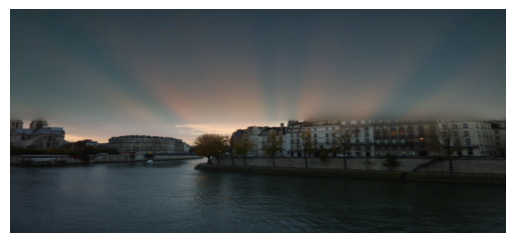

In [55]:
imgA = (cv2.imread("sun_set.jpg") / 255.0).astype(np.float32)
imgB = (cv2.imread("paris_1b.jpg") / 255.0).astype(np.float32)

imgA = cv2.cvtColor(imgA, cv2.COLOR_BGR2RGB)
imgB = cv2.cvtColor(imgB, cv2.COLOR_BGR2RGB)

# Ensure images have the same dimensions for blending
h, w, _ = imgA.shape # Get dimensions from imgA
imgB = cv2.resize(imgB, (w, h), interpolation=cv2.INTER_AREA) # Resize imgB to match imgA's dimensions

# Create vertical mask (top = imgA, bottom = imgB)
mask = np.zeros((h, w), dtype=np.float32)
mask[:h//2, :] = 1  # top half from imgA

blended = laplacian_pyramid_blending(imgA, imgB, mask, levels=5)

import matplotlib.pyplot as plt
plt.imshow(blended)
plt.axis('off')
plt.show()